# Setup


In [27]:
import mne
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import scipy.stats as stats

In [28]:
d_control = mne.io.read_raw_fif("clean_final_data/part2_erp_control_clean_raw.fif", preload=True)
d_BB = mne.io.read_raw_fif("clean_final_data/part4_erp_BB_clean_raw.fif", preload=True)


events_control = mne.find_events(d_control, min_duration=0.002)
events_BB = mne.find_events(d_BB, min_duration=0.002)

Opening raw data file clean_final_data/part2_erp_control_clean_raw.fif...
    Range : 317235 ... 585216 =   1239.199 ...  2286.000 secs
Ready.
Reading 0 ... 267981  =      0.000 ...  1046.801 secs...
Opening raw data file clean_final_data/part4_erp_BB_clean_raw.fif...
    Range : 892371 ... 1143039 =   3485.824 ...  4464.996 secs
Ready.
Reading 0 ... 250668  =      0.000 ...   979.172 secs...
Finding events on: Status
Trigger channel Status has a non-zero initial value of 31 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1492 events found on stim channel Status
Event IDs: [    1     2    10    11    12    20   101   102   104   105   107   108
   113   114   126   127   141   142   151   152 65536]
Finding events on: Status
Trigger channel Status has a non-zero initial value of 31 (consider using initial_event=True to detect this event)
Removing orphaned offset at the beginning of the file.
1496 events found on stim chann

# Prepare Epochs

In [29]:
stimulus_event_ids = {
    '0%/Left': 101,   '0%/Right': 102,
    '3%/Left': 104,   '3%/Right': 105,
    '6%/Left': 107,   '6%/Right': 108,
    '12%/Left': 113,  '12%/Right': 114,
    '25%/Left': 126,  '25%/Right': 127,
    '50%/Left': 151,  '50%/Right': 152
}

response_event_ids = {
    'Response/Left': 1,   
    'Response/Right': 2
}


epochs_control_stim = mne.Epochs(
    d_control, events_control, event_id=stimulus_event_ids, 
    tmin=-0.2, tmax=1.0, baseline=(None, 0), preload=True
)
epochs_BB_stim = mne.Epochs(
    d_BB, events_BB, event_id=stimulus_event_ids, 
    tmin=-0.2, tmax=1.0, baseline=(None, 0), preload=True
)

# --- Response-Locked (-800ms to +200ms, NO baseline) ---
epochs_control_resp = mne.Epochs(
    d_control, events_control, event_id=response_event_ids, 
    tmin=-0.8, tmax=0.2, baseline=None, preload=True
)
epochs_BB_resp = mne.Epochs(
    d_BB, events_BB, event_id=response_event_ids, 
    tmin=-0.8, tmax=0.2, baseline=None, preload=True
)



Not setting metadata
480 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 480 events and 308 original time points ...
12 bad epochs dropped
Not setting metadata
480 matching events found
Setting baseline interval to [-0.19921875, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 480 events and 308 original time points ...
8 bad epochs dropped
Not setting metadata
489 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 489 events and 257 original time points ...
9 bad epochs dropped
Not setting metadata
494 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 494 events and 257 original time points ...
6 bad epochs dropped


In [30]:
epochs_control_stim_csd = mne.preprocessing.compute_current_source_density(epochs_control_stim)
epochs_BB_stim_csd = mne.preprocessing.compute_current_source_density(epochs_BB_stim)
epochs_control_resp_csd = mne.preprocessing.compute_current_source_density(epochs_control_resp)
epochs_BB_resp_csd = mne.preprocessing.compute_current_source_density(epochs_BB_resp)



# Stimulus-Locked Evokeds
evoked_control_stim_cpp = epochs_control_stim_csd.average().filter(l_freq=None, h_freq=None)
evoked_BB_stim_cpp = epochs_BB_stim_csd.average().filter(l_freq=None, h_freq=None)

evoked_control_stim_cpp.comment = 'Control (Stimulus-Locked)'
evoked_BB_stim_cpp.comment = 'Binaural Beats (Stimulus-Locked)'

# Response-Locked Evokeds
evoked_control_resp_cpp = epochs_control_resp_csd.average().filter(l_freq=None, h_freq=None)
evoked_BB_resp_cpp = epochs_BB_resp_csd.average().filter(l_freq=None, h_freq=None)

evoked_control_resp_cpp.comment = 'Control (Response-Locked)'
evoked_BB_resp_cpp.comment = 'Binaural Beats (Response-Locked)'

Fitted sphere radius:         95.0 mm
Origin head coordinates:      -0.0 -0.0 40.1 mm
Origin device coordinates:    -0.0 -0.0 40.1 mm
Fitted sphere radius:         95.0 mm
Origin head coordinates:      -0.0 -0.0 40.1 mm
Origin device coordinates:    -0.0 -0.0 40.1 mm
Fitted sphere radius:         95.0 mm
Origin head coordinates:      -0.0 -0.0 40.1 mm
Origin device coordinates:    -0.0 -0.0 40.1 mm
Fitted sphere radius:         95.0 mm
Origin head coordinates:      -0.0 -0.0 40.1 mm
Origin device coordinates:    -0.0 -0.0 40.1 mm

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal allpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Filter length: 1 samples (0.004 s)


FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal allpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple a

In [31]:
# Plot 1: Stimulus-Locked CPP

combining channels using "mean"
combining channels using "mean"


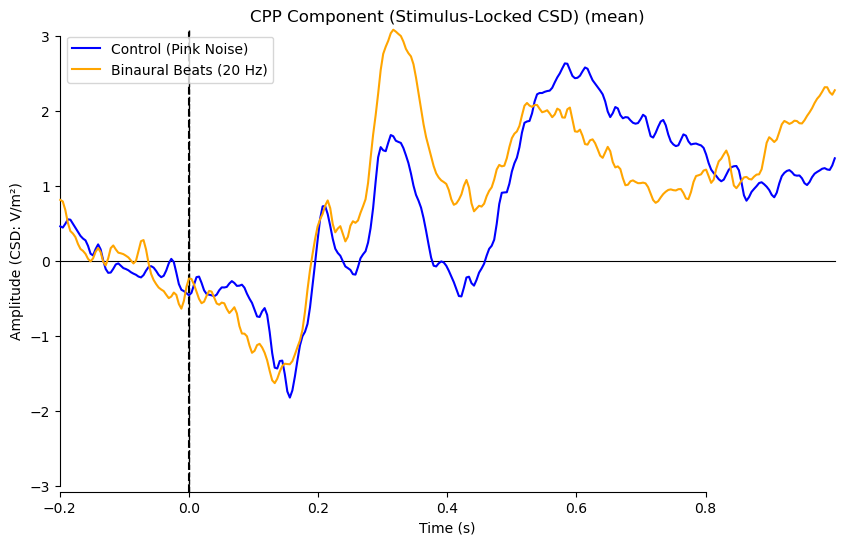

In [32]:

valid_cpp_channels = [ch for ch in ['CPz', 'Pz', 'CP1', 'CP2'] if ch in evoked_control_stim_cpp.ch_names]

fig_stim, ax_stim = plt.subplots(figsize=(10, 6))
mne.viz.plot_compare_evokeds(
    {'Control (Pink Noise)': evoked_control_stim_cpp, 
     'Binaural Beats (20 Hz)': evoked_BB_stim_cpp},
    picks=valid_cpp_channels,
    combine='mean', 
    axes=ax_stim,
    title='CPP Component (Stimulus-Locked CSD)',
    colors={'Control (Pink Noise)': 'blue', 'Binaural Beats (20 Hz)': 'orange'},
    show=False
)

# For Stimulus-Locked, t=0 is when the dots appeared on screen
ax_stim.axvline(0, color='black', linestyle='--', label='Stimulus Onset')
ax_stim.set_ylabel('Amplitude (CSD: V/m²)')
ax_stim.set_xlabel('Time (s)')
plt.show()



# Plot 2: Response-Locked CPP

combining channels using "mean"


combining channels using "mean"


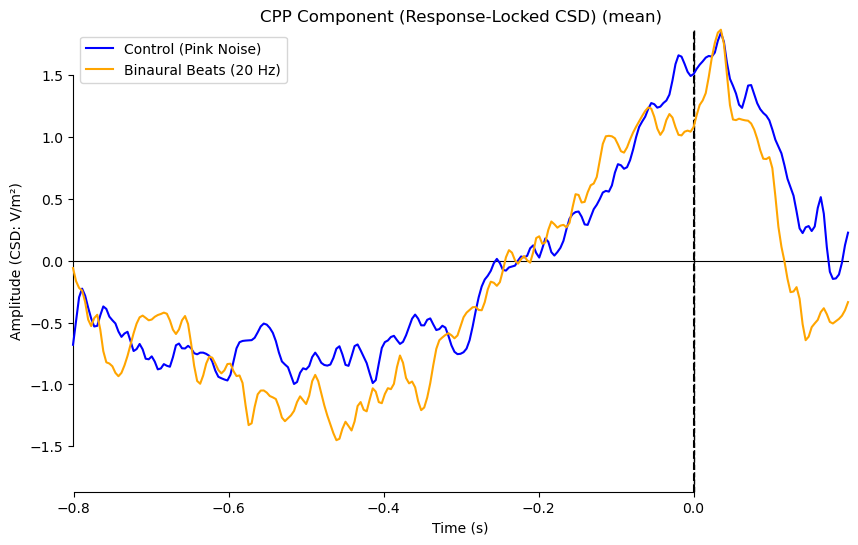

In [33]:

fig_resp, ax_resp = plt.subplots(figsize=(10, 6))
mne.viz.plot_compare_evokeds(
    {'Control (Pink Noise)': evoked_control_resp_cpp, 
     'Binaural Beats (20 Hz)': evoked_BB_resp_cpp},
    picks=valid_cpp_channels,
    combine='mean', 
    axes=ax_resp,
    title='CPP Component (Response-Locked CSD)',
    colors={'Control (Pink Noise)': 'blue', 'Binaural Beats (20 Hz)': 'orange'},
    show=False
)

# For Response-Locked, t=0 is the exact moment they pressed the button
ax_resp.axvline(0, color='black', linestyle='--', label='Button Press')
ax_resp.set_ylabel('Amplitude (CSD: V/m²)')
ax_resp.set_xlabel('Time (s)')
plt.show()

# By coherence

Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 339 samples (1.324 s)

Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 339 samples (1.324 s)

Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) m

/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/782087524.py:8: RuntimeWarning: filter_length (339) is longer than the signal (308), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_ctrl_stim_coh = {coh: epochs_control_stim_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}
/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/782087524.py:8: RuntimeWarning: filter_length (339) is longer than the signal (308), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_ctrl_stim_coh = {coh: epochs_control_stim_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}
/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/782087524.py:8: RuntimeWarning: filter_length (339) is longer than the signal (308), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_ctrl_stim_coh = {coh: epochs_control_stim_csd[coh].average().filter(None, 10.0) for coh in cohe

Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 339 samples (1.324 s)

Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 339 samples (1.324 s)

Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) m

/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/782087524.py:9: RuntimeWarning: filter_length (339) is longer than the signal (308), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_BB_stim_coh = {coh: epochs_BB_stim_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}
/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/782087524.py:9: RuntimeWarning: filter_length (339) is longer than the signal (308), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_BB_stim_coh = {coh: epochs_BB_stim_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}
/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/782087524.py:9: RuntimeWarning: filter_length (339) is longer than the signal (308), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_BB_stim_coh = {coh: epochs_BB_stim_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}
/var/fo

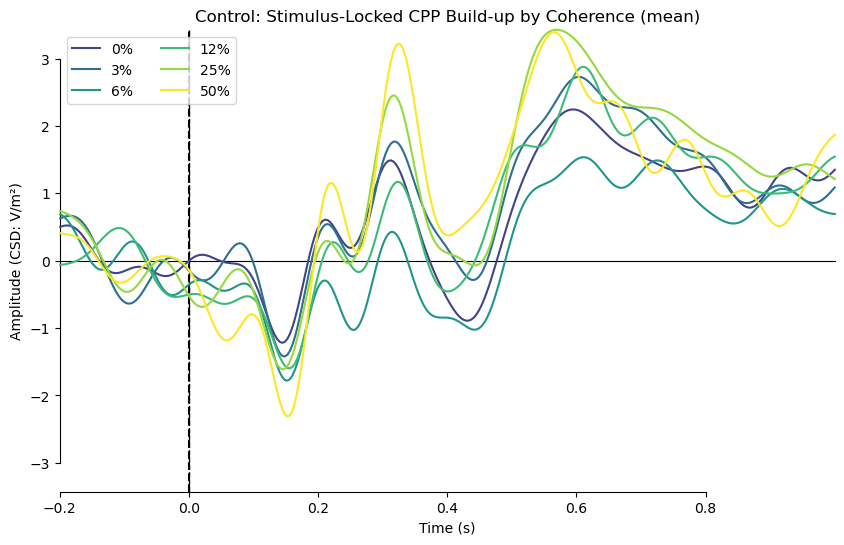

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


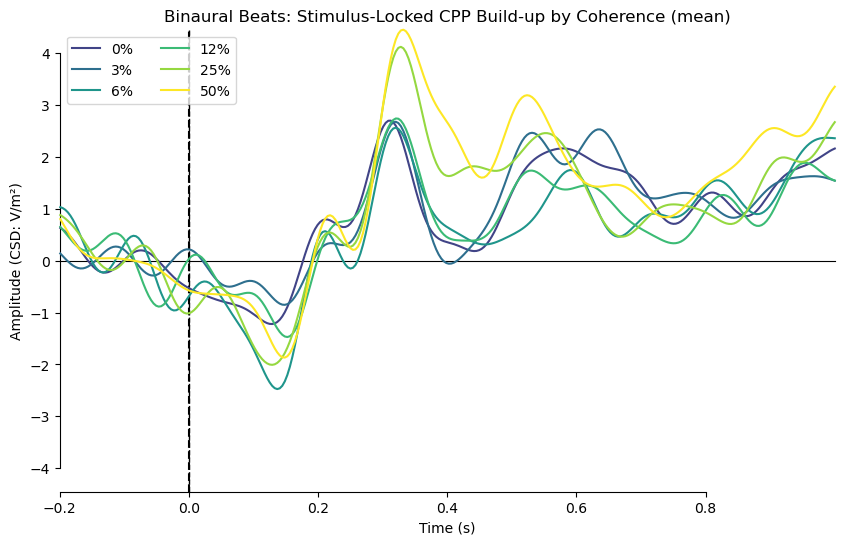

In [34]:

# 1. Define colors to avoid the MNE "unhashable type" bug
coherence_levels = ['0%', '3%', '6%', '12%', '25%', '50%']
colors = cm.viridis(np.linspace(0.2, 1, len(coherence_levels)))
color_dict = {coh: mcolors.to_hex(color) for coh, color in zip(coherence_levels, colors)}
valid_cpp_channels = [ch for ch in ['CPz', 'Pz', 'CP1', 'CP2'] if ch in epochs_control_stim_csd.ch_names]

# 2. Average and apply 10Hz Low-Pass Filter by coherence level dynamically
evokeds_ctrl_stim_coh = {coh: epochs_control_stim_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}
evokeds_BB_stim_coh = {coh: epochs_BB_stim_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}

# ==========================================
# Plot Control Condition
# ==========================================
fig_ctrl, ax_ctrl = plt.subplots(figsize=(10, 6))
mne.viz.plot_compare_evokeds(
    evokeds_ctrl_stim_coh, picks=valid_cpp_channels, combine='mean', axes=ax_ctrl,
    title='Control: Stimulus-Locked CPP Build-up by Coherence', colors=color_dict, show=False
)
ax_ctrl.axvline(0, color='black', linestyle='--', label='Stimulus Onset')
ax_ctrl.set_ylabel('Amplitude (CSD: V/m²)')
ax_ctrl.set_xlabel('Time (s)')
plt.show()

# ==========================================
# Plot Binaural Beats (20 Hz) Condition
# ==========================================
fig_bb, ax_bb = plt.subplots(figsize=(10, 6))
mne.viz.plot_compare_evokeds(
    evokeds_BB_stim_coh, picks=valid_cpp_channels, combine='mean', axes=ax_bb,
    title='Binaural Beats: Stimulus-Locked CPP Build-up by Coherence', colors=color_dict, show=False
)
ax_bb.axvline(0, color='black', linestyle='--', label='Stimulus Onset')
ax_bb.set_ylabel('Amplitude (CSD: V/m²)')
ax_bb.set_xlabel('Time (s)')
plt.show()

Not setting metadata
476 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 476 events and 257 original time points ...
9 bad epochs dropped
Not setting metadata
480 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 480 events and 257 original time points ...
6 bad epochs dropped
Fitted sphere radius:         96.3 mm
Origin head coordinates:      -0.8 14.6 43.2 mm
Origin device coordinates:    -0.8 14.6 43.2 mm
Fitted sphere radius:         96.3 mm
Origin head coordinates:      -0.8 14.6 43.2 mm
Origin device coordinates:    -0.8 14.6 43.2 mm
Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 10.00 Hz
- Upper transition bandw

/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/3269452405.py:50: RuntimeWarning: filter_length (339) is longer than the signal (257), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_ctrl_resp_coh = {coh: epochs_control_resp_coh_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}
/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/3269452405.py:50: RuntimeWarning: filter_length (339) is longer than the signal (257), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_ctrl_resp_coh = {coh: epochs_control_resp_coh_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}
/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/3269452405.py:50: RuntimeWarning: filter_length (339) is longer than the signal (257), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_ctrl_resp_coh = {coh: epochs_control_resp_coh_csd[coh].average().filter(None, 10.

Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 339 samples (1.324 s)

Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 339 samples (1.324 s)

Setting up low-pass filter at 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) m

/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/3269452405.py:51: RuntimeWarning: filter_length (339) is longer than the signal (257), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_BB_resp_coh = {coh: epochs_BB_resp_coh_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}
/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/3269452405.py:51: RuntimeWarning: filter_length (339) is longer than the signal (257), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_BB_resp_coh = {coh: epochs_BB_resp_coh_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}
/var/folders/73/wh5gtdmx657616cfwn4y1kd80000gn/T/ipykernel_2036/3269452405.py:51: RuntimeWarning: filter_length (339) is longer than the signal (257), distortion is likely. Reduce filter length or filter a longer signal.
  evokeds_BB_resp_coh = {coh: epochs_BB_resp_coh_csd[coh].average().filter(None, 10.0) for coh in coheren

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


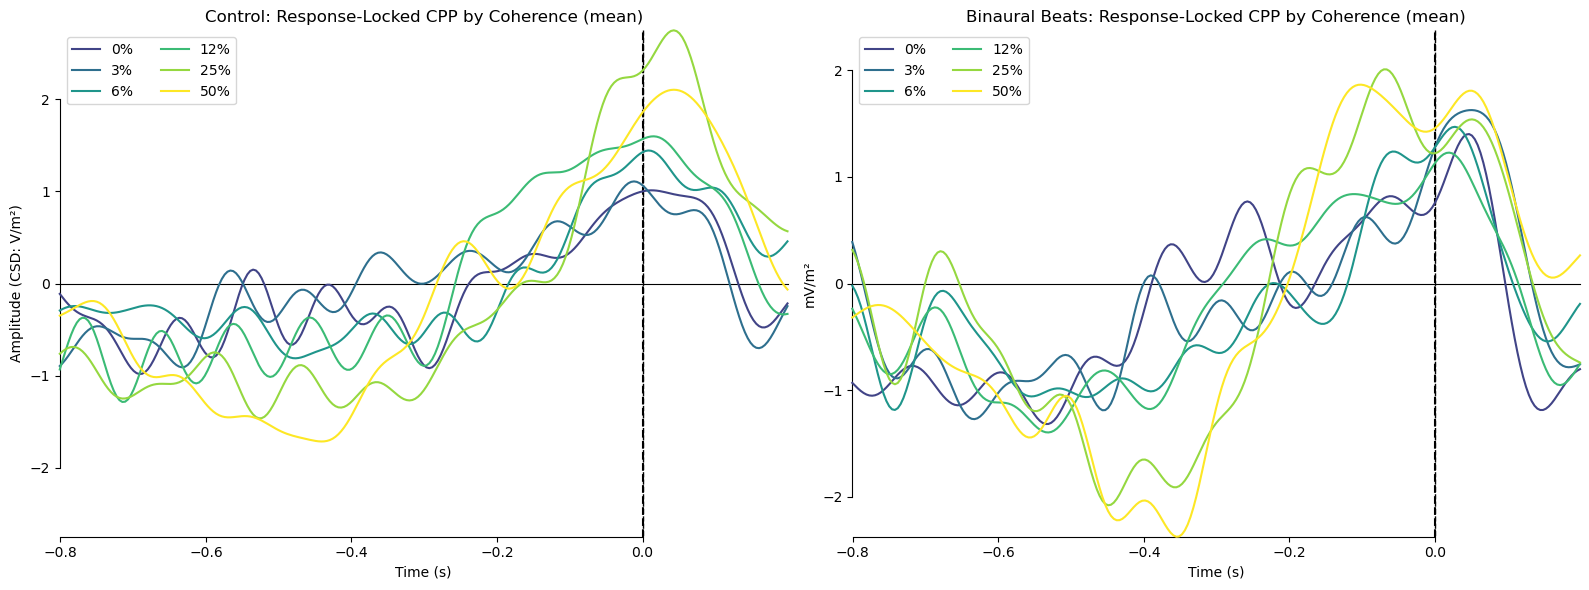

In [35]:
# 1. Function to map stimulus coherence onto the subsequent button press
def relabel_responses_with_coherence(events, stim_id_dict):
    # Create reverse lookup: e.g., 104 -> '3%/Left'
    stim_inv = {v: k for k, v in stim_id_dict.items()}
    
    new_events = []
    new_event_ids = {}
    
    for i in range(1, len(events)):
        current_trigger = events[i, 2]
        prev_trigger = events[i-1, 2]
        
        # If the current event is a response (1 or 2) AND previous was a stimulus
        if current_trigger in [1, 2] and prev_trigger in stim_inv:
            stim_name = stim_inv[prev_trigger] # e.g., '3%/Left'
            
            # Create a custom trigger number (+200 so it doesn't overlap with stims)
            new_trigger = prev_trigger + 200 
            # Rename it for MNE grouping (e.g., '3%/RespLeft')
            new_name = stim_name.replace('Left', 'RespLeft').replace('Right', 'RespRight')
            
            new_events.append([events[i, 0], events[i, 1], new_trigger])
            new_event_ids[new_name] = new_trigger
            
    return np.array(new_events), new_event_ids

# 2. Generate the new coherence-labeled response events
resp_events_control_coh, resp_event_ids_coh = relabel_responses_with_coherence(events_control, stimulus_event_ids)
resp_events_BB_coh, _ = relabel_responses_with_coherence(events_BB, stimulus_event_ids)

# 3. Epoch the data using these NEW events
epochs_control_resp_coh = mne.Epochs(
    d_control, resp_events_control_coh, event_id=resp_event_ids_coh, 
    tmin=-0.8, tmax=0.2, baseline=None, preload=True
)
epochs_BB_resp_coh = mne.Epochs(
    d_BB, resp_events_BB_coh, event_id=resp_event_ids_coh, 
    tmin=-0.8, tmax=0.2, baseline=None, preload=True
)

# 4. Clean, Montage, and CSD Transform (Skipping explicit bad channel drops for brevity, assuming standard clean)
montage = mne.channels.make_standard_montage('standard_1020')
epochs_control_resp_coh.set_montage(montage)
epochs_BB_resp_coh.set_montage(montage)

epochs_control_resp_coh_csd = mne.preprocessing.compute_current_source_density(epochs_control_resp_coh)
epochs_BB_resp_coh_csd = mne.preprocessing.compute_current_source_density(epochs_BB_resp_coh)

# 5. Average and filter by Coherence
evokeds_ctrl_resp_coh = {coh: epochs_control_resp_coh_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}
evokeds_BB_resp_coh = {coh: epochs_BB_resp_coh_csd[coh].average().filter(None, 10.0) for coh in coherence_levels}

# ==========================================
# Plot Response-Locked
# ==========================================
fig_resp, ax_resp = plt.subplots(1, 2, figsize=(16, 6)) # Plotting side-by-side!

# Control
mne.viz.plot_compare_evokeds(
    evokeds_ctrl_resp_coh, picks=valid_cpp_channels, combine='mean', axes=ax_resp[0],
    title='Control: Response-Locked CPP by Coherence', colors=color_dict, show=False
)
ax_resp[0].axvline(0, color='black', linestyle='--', label='Button Press')
ax_resp[0].set_ylabel('Amplitude (CSD: V/m²)')

# Binaural Beats
mne.viz.plot_compare_evokeds(
    evokeds_BB_resp_coh, picks=valid_cpp_channels, combine='mean', axes=ax_resp[1],
    title='Binaural Beats: Response-Locked CPP by Coherence', colors=color_dict, show=False
)
ax_resp[1].axvline(0, color='black', linestyle='--', label='Button Press')

plt.tight_layout()
plt.show()

# Overall build-up with fitted slopes

--- Kontrol (Response-Locked) ---
Slope (Pre-response Rate): 7.324e-03 V/m²/s
Slope Standard Error:      2.451e-04
R-squared:                 0.937
P-value (Slope != 0):      0.0000

--- Binaural Beats (Response-Locked) ---
Slope (Pre-response Rate): 6.059e-03 V/m²/s
Slope Standard Error:      2.371e-04
R-squared:                 0.916
P-value (Slope != 0):      0.0000



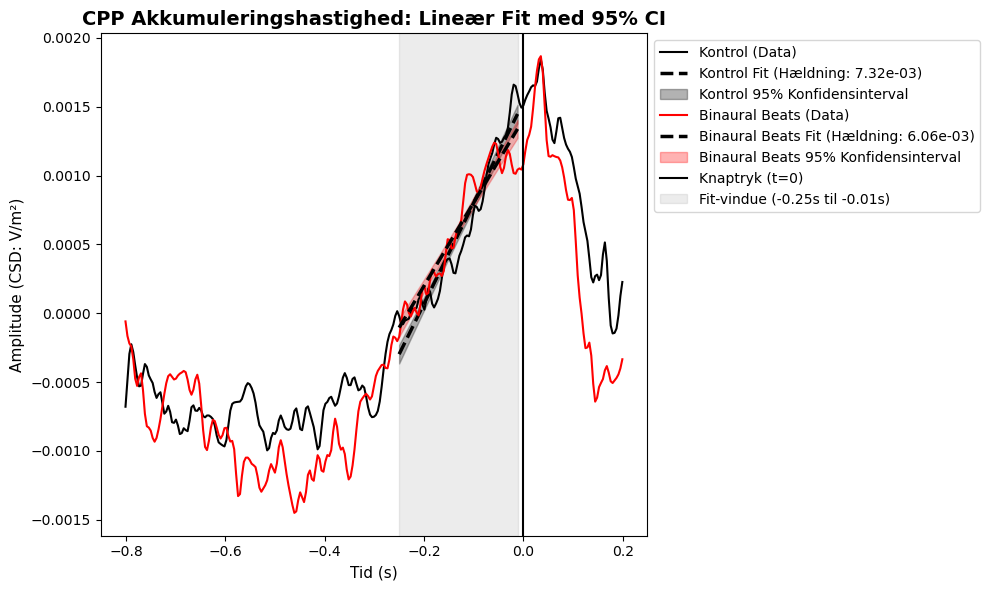

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Definer det tidsvindue før responsen, hvor signalet akkumuleres (Negativ tid)
tmin_fit_resp = -0.25  # 250 ms FØR respons
tmax_fit_resp = -0.01  # 10 ms FØR respons

def fit_and_plot_resp_slope_with_error(evoked, color, label, ax):
    """Fitter en linje til CPP før respons, beregner 95% CI og plotter det."""
    
    # Udtræk data specifikt for det negative tidsvindue
    evoked_window = evoked.copy().crop(tmin=tmin_fit_resp, tmax=tmax_fit_resp)
    times = evoked_window.times
    
    # Hent amplitudedata, gennemsnit over de gyldige CPP-kanaler
    amplitudes = evoked_window.copy().pick(valid_cpp_channels).data.mean(axis=0)
    
    # Lineær regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(times, amplitudes)
    fitted_line = (slope * times) + intercept
    
    # --- Beregn 95% konfidensinterval (CI) for linjen ---
    n = len(times)
    t_val = stats.t.ppf(0.975, n - 2) # T-værdi for 95% CI (tosidet)
    
    # 1. Beregn residualer (forskel mellem faktiske data og den fittede linje)
    residuals = amplitudes - fitted_line
    # 2. Residual standardfejl
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2)) 
    # 3. Summen af de kvadrerede afvigelser for X
    ss_x = np.sum((times - np.mean(times))**2) 
    
    # 4. Beregn CI for hvert punkt langs X-aksen (times)
    ci = t_val * s_err * np.sqrt((1/n) + ((times - np.mean(times))**2 / ss_x))
    
    upper_bound = fitted_line + ci
    lower_bound = fitted_line - ci
    # -------------------------------------------------------
    
    # --- Plotting ---
    # Plot den fulde Evoked bølgeform
    full_times = evoked.times
    full_amps = evoked.copy().pick(valid_cpp_channels).data.mean(axis=0)
    # --- OVERSAT TIL DANSK ---
    ax.plot(full_times, full_amps, color=color, label=f'{label} (Data)')
    
    # Læg den tykke, stiplede fittede linje ovenpå
    # --- OVERSAT TIL DANSK ---
    ax.plot(times, fitted_line, color='black', linestyle='--', linewidth=2.5, 
            label=f'{label} Fit (Hældning: {slope:.2e})')
            
    # Plot fejl-båndet (95% CI)
    # --- OVERSAT TIL DANSK ---
    ax.fill_between(times, lower_bound, upper_bound, color=color, alpha=0.3, 
                    label=f'{label} 95% Konfidensinterval')
    
    # Print den formelle statistik til konsollen (Holdes på engelsk til statistikbrug)
    print(f"--- {label} (Response-Locked) ---")
    print(f"Slope (Pre-response Rate): {slope:.3e} V/m²/s")
    print(f"Slope Standard Error:      {std_err:.3e}") 
    print(f"R-squared:                 {r_value**2:.3f}")
    print(f"P-value (Slope != 0):      {p_value:.4f}\n")


# 2. Opsætning af figuren
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Kør fit og plot for begge Response-Locked betingelser
# --- NAVNE OVERSAT TIL DANSK ---
fit_and_plot_resp_slope_with_error(evoked_control_resp_cpp, 'black', 'Kontrol', ax)
fit_and_plot_resp_slope_with_error(evoked_BB_resp_cpp, 'red', 'Binaural Beats', ax)

# 4. Udsmykning af plottet
# --- OVERSAT TIL DANSK ---
ax.axvline(0, color='black', linestyle='-', label='Knaptryk (t=0)')

# Skyggevirkning over det negative tidsvindue brugt til fittet
# --- OVERSAT TIL DANSK ---
ax.axvspan(tmin_fit_resp, tmax_fit_resp, color='gray', alpha=0.15, 
           label=f'Fit-vindue ({tmin_fit_resp}s til {tmax_fit_resp}s)')

# --- DANSKE TITLER OG AKSENAVNE ---
ax.set_title('CPP Akkumuleringshastighed: Lineær Fit med 95% CI', fontsize=14, fontweight='bold')
ax.set_ylabel('Amplitude (CSD: V/m²)', fontsize=11)
ax.set_xlabel('Tid (s)', fontsize=11)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

# Export data

In [39]:
import pandas as pd

# We will store all the data points in a list, then convert to a DataFrame
data_rows = []

# Loop through the Control condition
for coh, evoked in evokeds_ctrl_resp_coh.items():
    times = evoked.times
    # Isolate the CPP channels and average them together (just like plotting)
    amplitudes = evoked.copy().pick(valid_cpp_channels).data.mean(axis=0)
    
    # Add each timepoint as a row
    for t, amp in zip(times, amplitudes):
        data_rows.append({
            'Condition': 'Control',
            'Coherence': coh,
            'Time': t,
            'Amplitude': amp
        })

# Loop through the Binaural Beats (BB) condition
for coh, evoked in evokeds_BB_resp_coh.items():
    times = evoked.times
    amplitudes = evoked.copy().pick(valid_cpp_channels).data.mean(axis=0)
    
    for t, amp in zip(times, amplitudes):
        data_rows.append({
            'Condition': 'BB',
            'Coherence': coh,
            'Time': t,
            'Amplitude': amp
        })

# Convert to a pandas DataFrame
df = pd.DataFrame(data_rows)

# Create a numeric version of coherence (e.g., '3%' -> 3) which is often easier for R regression
df['Coherence_Num'] = df['Coherence'].str.replace('%', '').astype(float)

# Save to CSV in your current working directory
csv_filename = 'cpp_response_locked_data.csv'
df.to_csv(csv_filename, index=False)


In [41]:
import pandas as pd
import scipy.stats as stats

# 1. Define the Pre-Response "Build-up" Time Window
tmin_fit_resp = -0.45 
tmax_fit_resp = -0.20

# 2. List to store the data for our CSV
single_trial_data = []

# 3. Helper function to extract slopes
def extract_single_trial_slopes(epochs_obj, condition_name):
    # Crop to our specific time window
    epochs_window = epochs_obj.copy().crop(tmin=tmin_fit_resp, tmax=tmax_fit_resp)
    times = epochs_window.times
    
    # Iterate through all event IDs (e.g., '3%/RespLeft', '50%/RespRight')
    for event_name in epochs_window.event_id.keys():
        
        # Extract the coherence number string (e.g., "3" from "3%/RespLeft")
        coherence_level = event_name.split('%')[0] 
        
        # Get the raw data array for this specific event type
        # Shape: (number_of_trials, channels, timepoints)
        raw_data = epochs_window[event_name].copy().pick(valid_cpp_channels).get_data()
        
        # Average across the spatial CPP channels
        # Shape becomes: (number_of_trials, timepoints)
        trial_data_avg_channels = raw_data.mean(axis=1)
        
        # Loop through every single trial and fit a line!
        for trial_idx, trial_amplitudes in enumerate(trial_data_avg_channels):
            slope, intercept, r, p, err = stats.linregress(times, trial_amplitudes)
            
            single_trial_data.append({
                'Condition': condition_name,
                'Coherence': int(coherence_level), # Save as integer
                'Trial_Number': trial_idx + 1,
                'Slope': slope,
                'R_squared': r**2
            })

# 4. Run the extraction for both conditions
print("Extracting Control slopes...")
extract_single_trial_slopes(epochs_control_resp_coh, 'Control')

print("Extracting Binaural Beats slopes...")
extract_single_trial_slopes(epochs_BB_resp_coh, 'BB')

# 5. Convert to Pandas DataFrame and Export
df_single_trials = pd.DataFrame(single_trial_data)
csv_filename = 'single_trial_slopes.csv'
df_single_trials.to_csv(csv_filename, index=False)

print(f"\nSuccess! Exported {len(df_single_trials)} single-trial slopes to {csv_filename}.")
print(df_single_trials.head())

Extracting Control slopes...
Extracting Binaural Beats slopes...

Success! Exported 941 single-trial slopes to single_trial_slopes.csv.
  Condition  Coherence  Trial_Number     Slope  R_squared
0   Control          0             1 -0.000025   0.477411
1   Control          0             2  0.000005   0.020710
2   Control          0             3  0.000016   0.197484
3   Control          0             4 -0.000008   0.038948
4   Control          0             5 -0.000008   0.030291


In [42]:
import pandas as pd
import numpy as np

# 1. Define the Peak Threshold Window (Right around the button press: t=0)
tmin_peak = -0.05  # 50 ms BEFORE response
tmax_peak =  0.05  # 50 ms AFTER response

single_trial_peaks = []

def extract_single_trial_peaks(epochs_obj, condition_name):
    # Crop to the threshold window
    epochs_window = epochs_obj.copy().crop(tmin=tmin_peak, tmax=tmax_peak)
    
    for event_name in epochs_window.event_id.keys():
        coherence_level = event_name.split('%')[0] 
        
        # Get data: (trials, channels, timepoints)
        raw_data = epochs_window[event_name].copy().pick(valid_cpp_channels).get_data()
        
        # 1. Average across the spatial CPP channels
        # 2. Average across the narrow 100ms time window to get ONE number per trial
        trial_peaks = raw_data.mean(axis=1).mean(axis=1) 
        
        for trial_idx, peak_amp in enumerate(trial_peaks):
            single_trial_peaks.append({
                'Condition': condition_name,
                'Coherence': int(coherence_level),
                'Trial_Number': trial_idx + 1,
                'Peak_Amplitude': peak_amp
            })

print("Extracting Control thresholds...")
extract_single_trial_peaks(epochs_control_resp_coh, 'Control')

print("Extracting BB thresholds...")
extract_single_trial_peaks(epochs_BB_resp_coh, 'BB')

# Export to CSV
df_peaks = pd.DataFrame(single_trial_peaks)
df_peaks.to_csv('single_trial_thresholds.csv', index=False)
print("Saved to single_trial_thresholds.csv")

Extracting Control thresholds...
Extracting BB thresholds...
Saved to single_trial_thresholds.csv
